<a href="https://colab.research.google.com/github/Uma17/Data-Science/blob/main/ML_PersonalLoanCampaign_Project_Notebook_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objectives

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Installing and Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data= pd.read_csv("/content/drive/MyDrive/Datasets/ML/Loan_Modelling.csv")

In [ ]:
df=data.copy()
print (df)

        ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  \
0        1   25           1      49    91107       4    1.6          1   
1        2   45          19      34    90089       3    1.5          1   
2        3   39          15      11    94720       1    1.0          1   
3        4   35           9     100    94112       1    2.7          2   
4        5   35           8      45    91330       4    1.0          2   
...    ...  ...         ...     ...      ...     ...    ...        ...   
4995  4996   29           3      40    92697       1    1.9          3   
4996  4997   30           4      15    92037       4    0.4          1   
4997  4998   63          39      24    93023       2    0.3          3   
4998  4999   65          40      49    90034       3    0.5          2   
4999  5000   28           4      83    92612       3    0.8          1   

      Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  \
0            0              0         

## Data Overview

* Observations
* Sanity checks

### Viewing the first and last 5 rows of the dataset

In [ ]:
df.head(30)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [ ]:
df.tail(30)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4970,4971,37,13,95,95821,2,1.70,2,0,0,0,0,0,1
4971,4972,58,28,73,90024,1,1.40,3,0,0,1,0,0,0
4972,4973,58,32,41,93401,3,2.20,3,148,0,0,0,1,1
4973,4974,31,1,68,95045,4,4.00,3,0,0,0,0,1,0
4974,4975,59,33,64,92867,4,1.70,2,0,0,0,0,0,1
4975,4976,38,11,29,95207,4,1.00,2,0,0,0,0,1,0
4976,4977,29,5,31,95039,1,1.80,2,0,0,0,0,1,1
4977,4978,40,15,54,90266,3,0.80,3,0,0,0,0,1,0
4978,4979,57,27,63,90210,4,2.00,3,0,0,0,0,1,0
4979,4980,50,26,92,90740,1,2.60,2,213,0,0,0,0,1


All the datas are numeric

* ID, Age,Experience, Income, Zipcode,CCAvg,Mortgage are all continuous numeric
* Personal Loan, Securities_Account, CD_Account,online, credit card are     binary categories by default.
* Education, Family - with binary values are categorical variables with ordinal data label encodingby default.




### Checking the shape of the dataset.

In [ ]:
df.shape

(5000, 14)

Insight : There are about 5000 rows and 14 columns

### Checking the attributes types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


There are about 14 numeric columns including 1 float

### Checking the statistical summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [ ]:
df.duplicated().sum()

np.int64(0)

Observation: No Duplicate values

### Checking for missing values

In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [ ]:
df.isnull().nunique()

,0
ID,1
Age,1
Experience,1
Income,1
ZIPCode,1
Family,1
CCAvg,1
Education,1
Mortgage,1
Personal_Loan,1


In [ ]:
df['ID'].nunique()

5000

Observation : No Missing values

## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

### Univariate Analysis

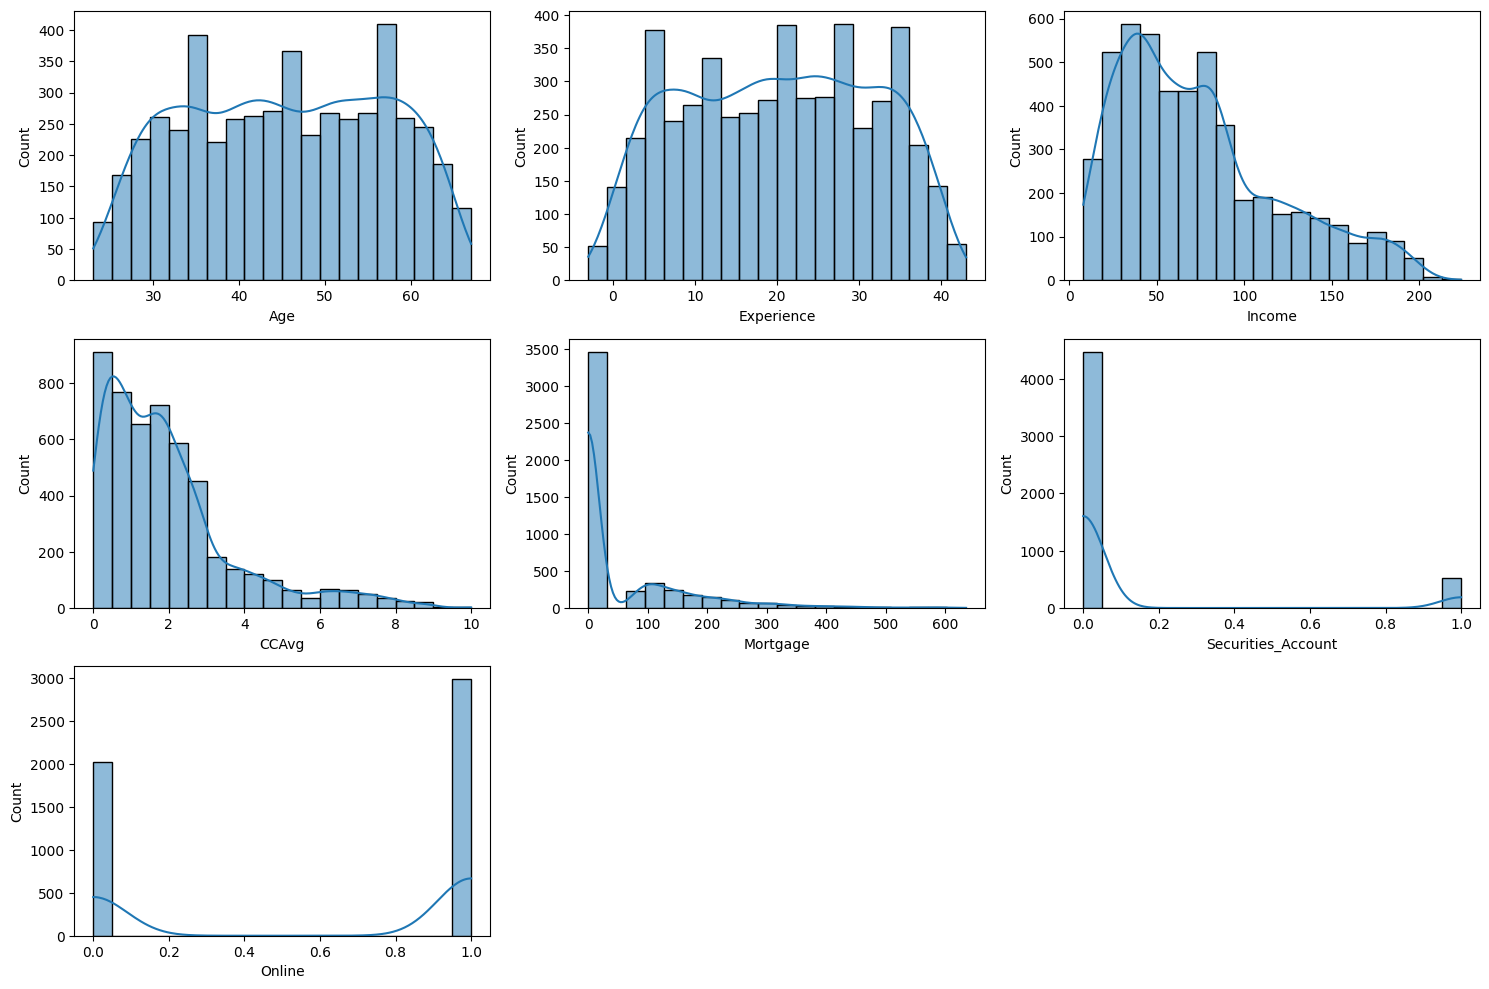

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage','Securities_Account',
                'Online']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=df, x=feature, kde = True, bins=20)    # plot the histogram


plt.tight_layout();   # to add spacing between plots

* Less than 500 of customers have CD_Account. Few customers have CD_Account
* About 3500 customers do not have Mortgage loan. Majority of customers do not have Mortgage
* CCAvg and Income is right skewed.Most customers earn moderate amounts around 100k. Most customers spend moderate on credit cards and few spend extrememly high amounts.
* Age and Experience- Age has stable linear relationship with target and has no extreme outliers.Many early career customers.

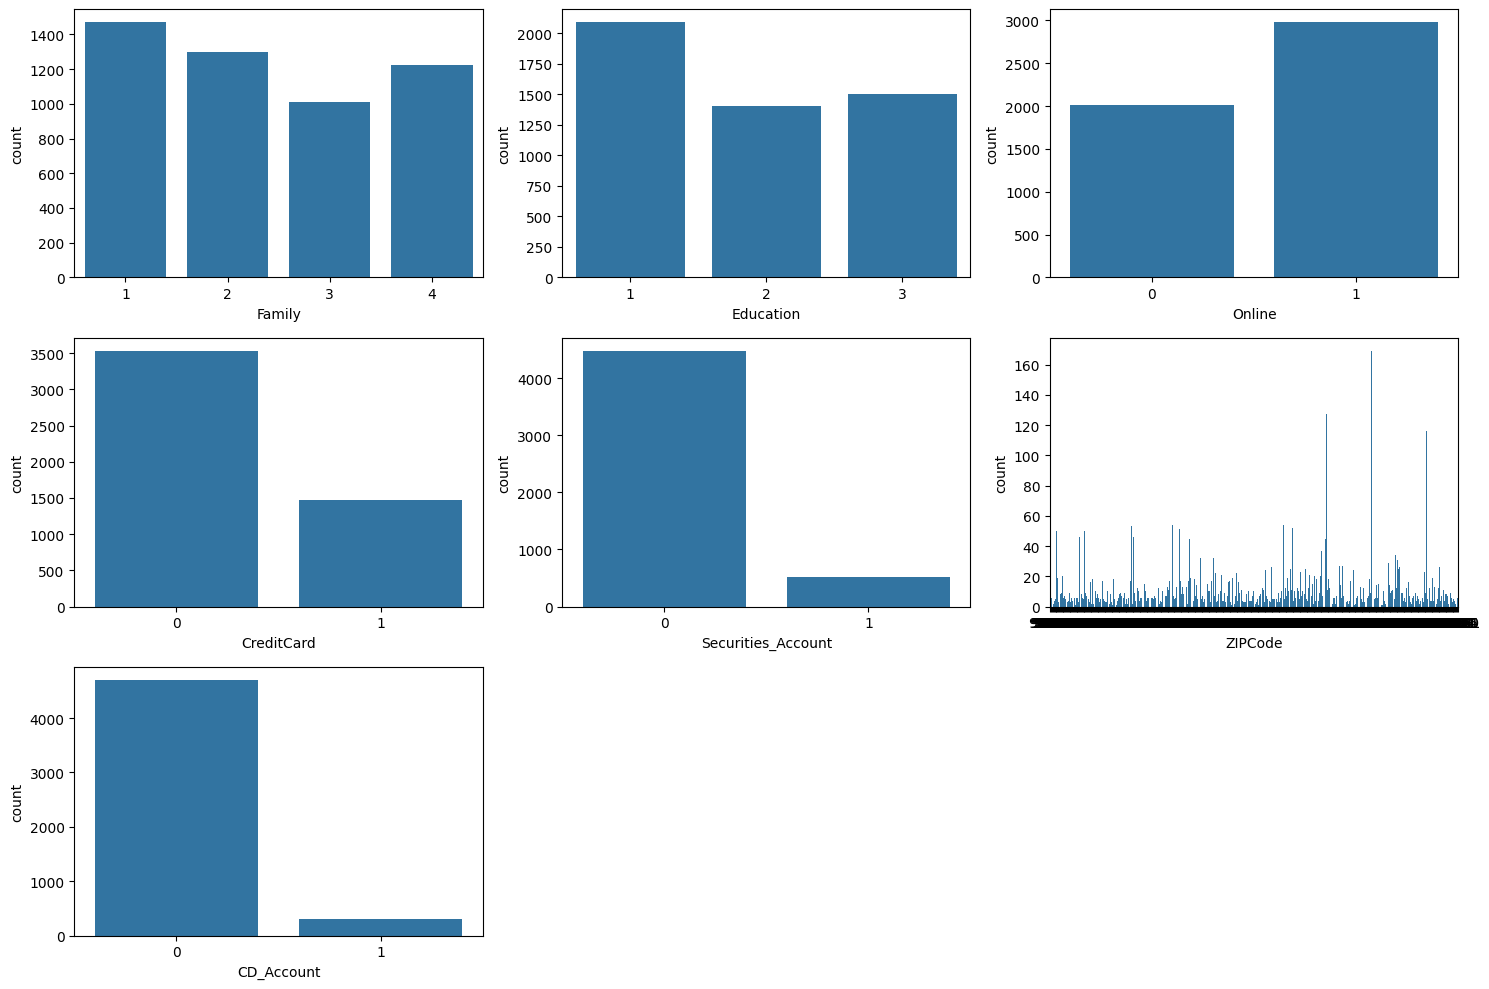

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Family','Education','Online','CreditCard','Securities_Account',
                'ZIPCode','CD_Account',]

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=df, x=feature)    # plot the histogram


plt.tight_layout();

Observation


* Most customers fall into Family = 1, with counts decreasing as family size increases.
* Education = 1 is the largest group, followed by 2 and 3.
*  Online = 1 has a higher count than Online = 0.
*  CreditCard = 0 is significantly higher than CreditCard = 1.
* Very few customers hold investment accounts.
* ZIPCode shows many categories with uneven counts.

### Bivariate Analysis

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

##### PersonalLoan Vs Family

Family            1     2     3     4   All
Personal_Loan                              
All            1472  1296  1010  1222  5000
0              1365  1190   877  1088  4520
1               107   106   133   134   480
------------------------------------------------------------------------------------------------------------------------


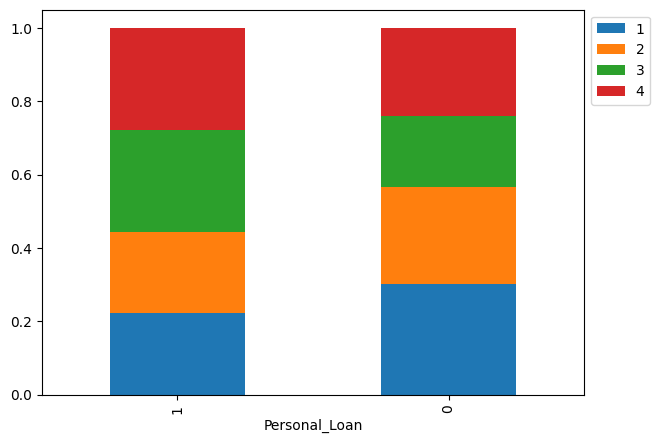

In [ ]:
stacked_barplot(data,'Personal_Loan', 'Family')

##### PersonalLoan Vs Securities_Account

Securities_Account     0    1   All
Personal_Loan                      
All                 4478  522  5000
0                   4058  462  4520
1                    420   60   480
------------------------------------------------------------------------------------------------------------------------


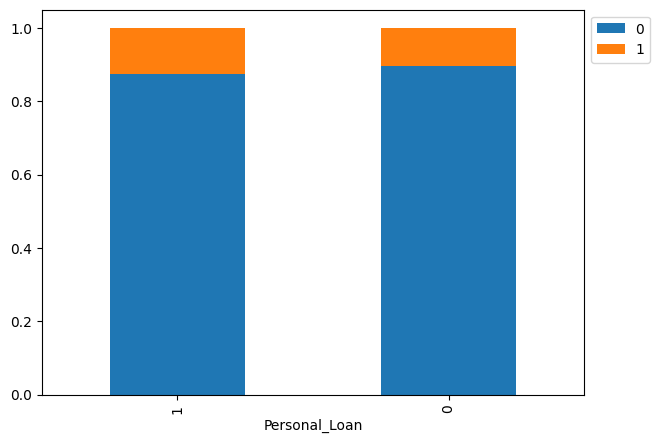

In [ ]:
stacked_barplot(data,'Personal_Loan', 'Securities_Account')

Observation:
Non–loan takers (0):

4,058 have no securities account

462 have a securities account

Loan takers (1):

420 have no securities account

60 have a securities account

##### PersonalLoan Vs CD_Account

CD_Account        0    1   All
Personal_Loan                 
All            4698  302  5000
0              4358  162  4520
1               340  140   480
------------------------------------------------------------------------------------------------------------------------


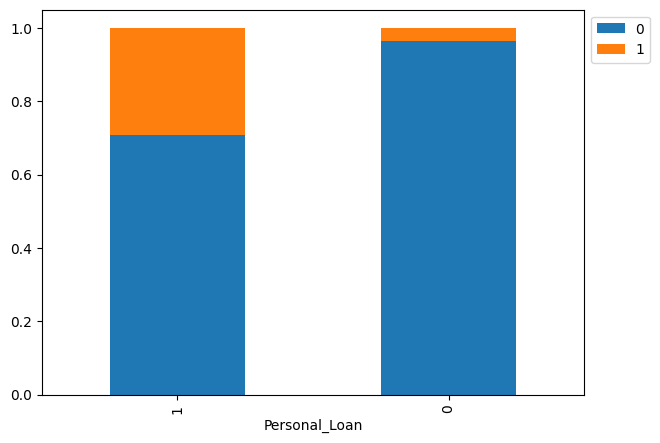

In [ ]:
stacked_barplot(data,'Personal_Loan','CD_Account')

Observation:
In 5000 customers 4520 customers have no personal loan and only 480 has loan.

Among non–loan takers (0):

* 4,358 have no CD account
* Only 162 have a CD account

Among loan takers (1):

* 340 have no CD account
* 140 have a CD account

##### PersonalLoan Vs Online


Online            0     1   All
Personal_Loan                  
All            2016  2984  5000
0              1827  2693  4520
1               189   291   480
------------------------------------------------------------------------------------------------------------------------


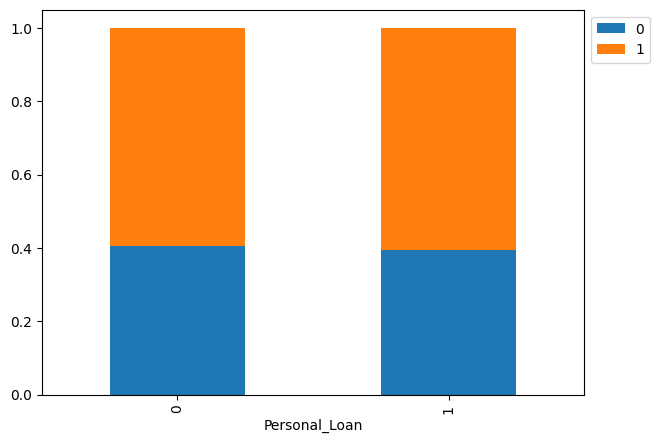

In [ ]:
stacked_barplot(data,'Personal_Loan','Online')

Observation:



* In 5000 customers 4520 customers have no personal loan and only 480 has loan.
* In 5000 customers 2016 customers do not use online and 2984 uses online.

Among 4520 non–loan takers (0):


* 1,827 do not use online banking
* 2,693 do use online banking

Among 480 loan takers (1):


* 189 do not use online banking
* 291 do use online banking

A larger share of loan takers and non-loan takers also  uses online banking.

##### PersonalLoan Vs CreditCard

CreditCard        0     1   All
Personal_Loan                  
All            3530  1470  5000
0              3193  1327  4520
1               337   143   480
------------------------------------------------------------------------------------------------------------------------


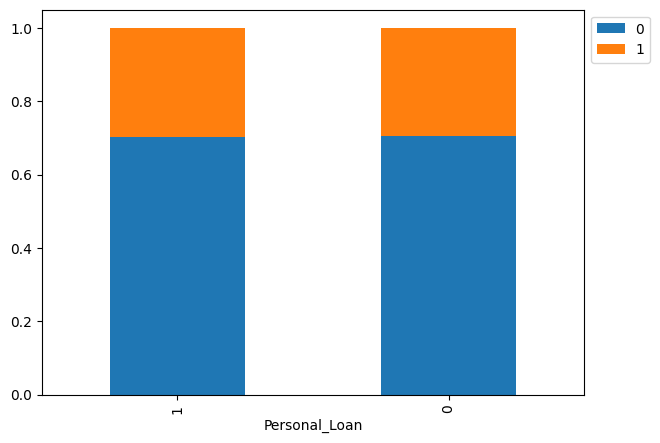

In [ ]:
stacked_barplot(data,'Personal_Loan','CreditCard')

Observation:

*  In 5000 customers 4520 customers have no personal loan and only 480 has loan.
* On 4520 non loaners -3,193 of them  have no credit card,1,327 have a credit card
* On 480 loaners 337 have no credit card and 143 have credit card
* Totally 1470 has credit card, 3530 has no credti cards

Box plot

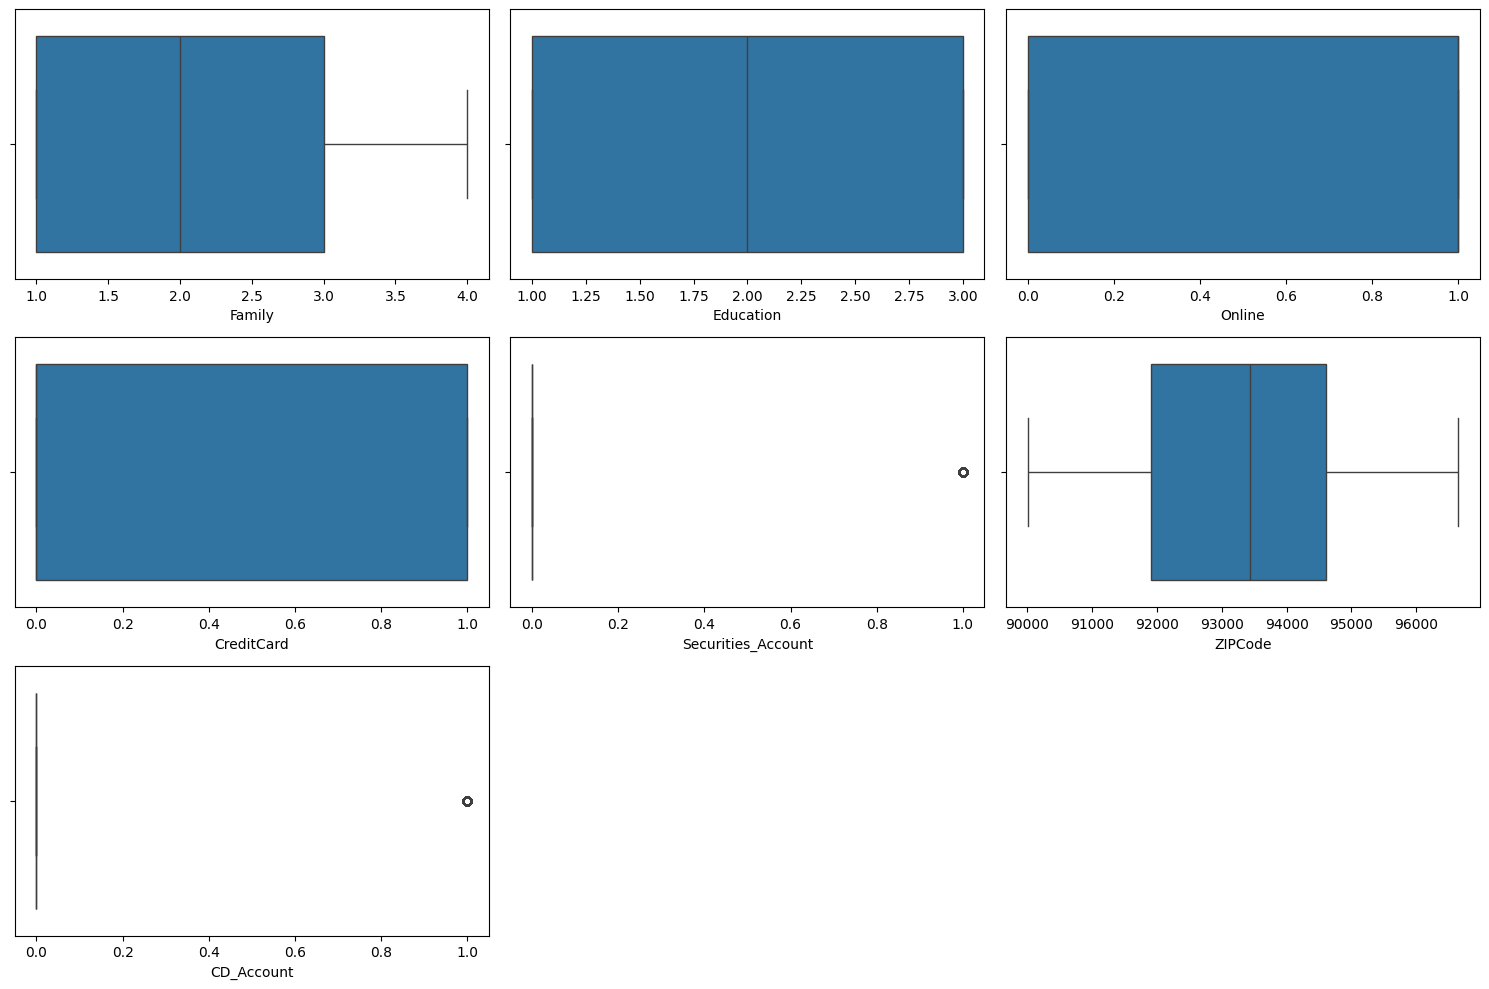

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

Insight:
* Income and CCAvg and Mortgage are right skewed.Large number of customers have a mortgage value of 0. Many customers do not have a home loan with the bank.
Outliers represents customers with large home loans.
* There are outliers in all the numerical attributes in the data



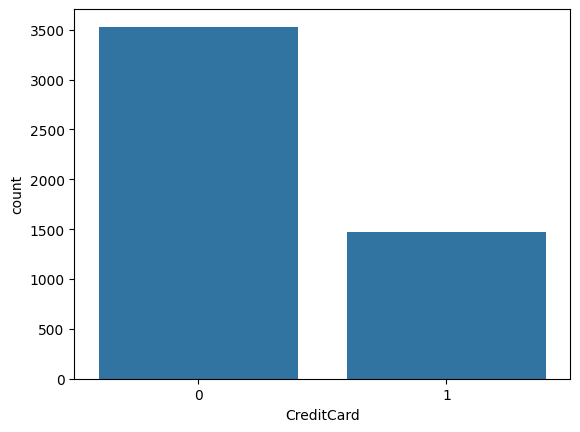

In [ ]:
sns.countplot(data=df, x='CreditCard');

Over 3500 customers have no credit card

Loan Vs education


<Axes: xlabel='Education', ylabel='Personal_Loan'>

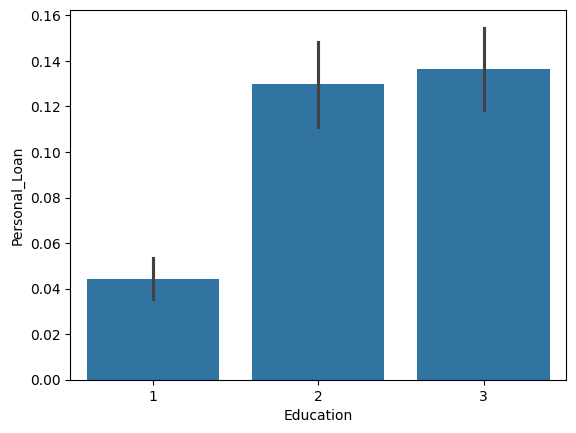

In [ ]:
# sns.countplot(data=df, x='Education', hue='Personal_Loan')
sns.barplot(data=df, x='Education', y='Personal_Loan', estimator='mean')



Loan acceptance tends to be higher for Graduate and Professional customers.

,Age,Experience
Age,1.000000,0.994215
Experience,0.994215,1.000000


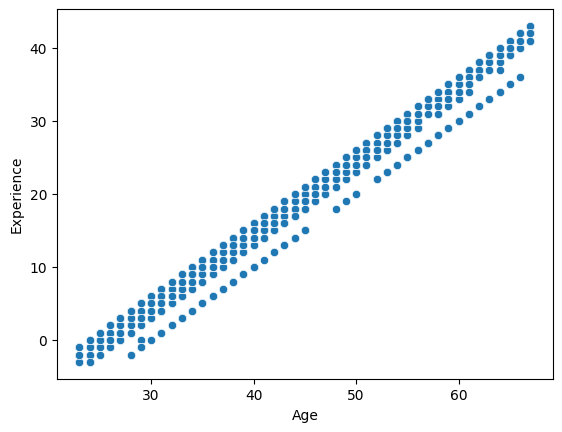

In [ ]:
sns.scatterplot(data=df, x='Age', y='Experience');
df[['Age', 'Experience']].corr()

Insight : age Vs experience -continuous numeric variables - (scatterfor correlation)shows a strong postive linear relationship and multicollinearity. SO drop Experience.

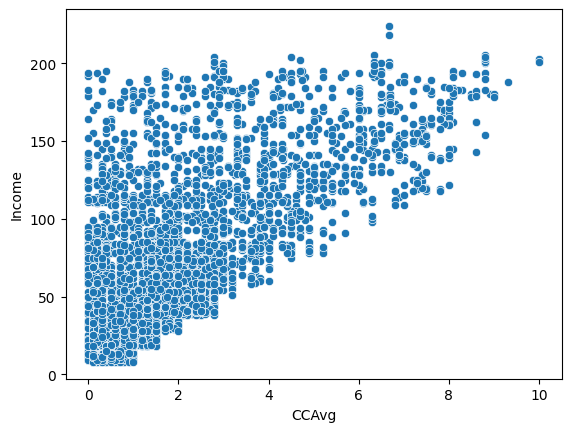

In [ ]:
sns.scatterplot(data=df, x='CCAvg', y='Income');



* CCAvg increases, Income also tends to increase.
* This indicates a positive correlation between credit card spending and income.



### Multivariate analysis

##### Income Vs CCAvg Vs CD_Account

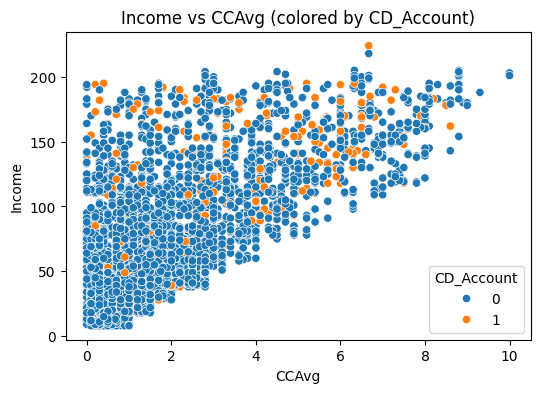

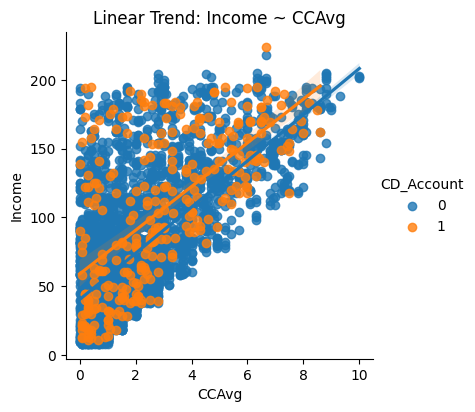

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='CCAvg', y='Income', hue='CD_Account')
plt.title("Income vs CCAvg (colored by CD_Account)")
plt.show()

# Add regression line
sns.lmplot(data=df, x='CCAvg', y='Income', hue='CD_Account', height=4)
plt.title("Linear Trend: Income ~ CCAvg")
plt.show()


* Income increases as CCAvg increases
* customers who spend more on their credit cards tend to have higher incomes

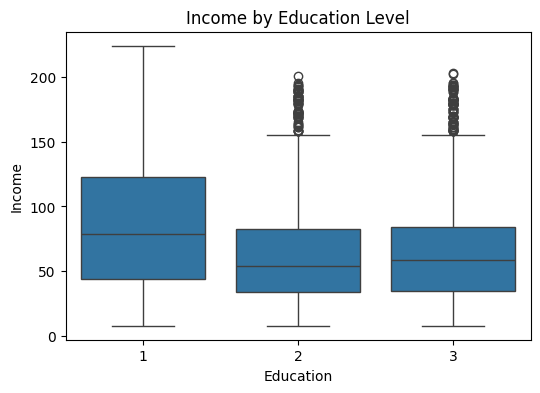

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Education', y='Income')
plt.title("Income by Education Level")
plt.show()

* Education level 1 has the highest median Income.  
* Education levels 2 and 3 have lower and similar median incomes.  
* All groups show outliers at the high end

Income Vs CD_Account

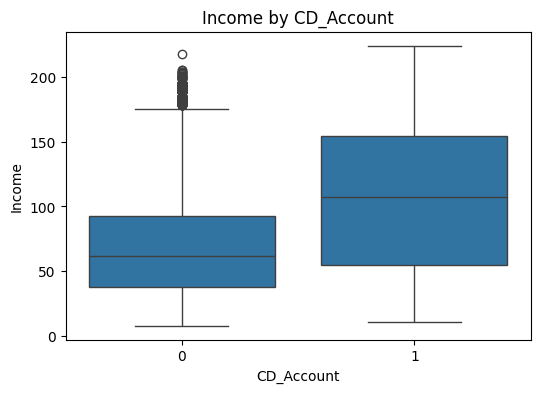

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='CD_Account', y='Income')
plt.title("Income by CD_Account")
plt.show()

* The median income for group 1 is much higher than for group 0.
* This means CD account holders tend to be a higher income
* Group 1 has a wider box and whiskers,which means More variability in income
and it shows a mix of moderately high and very high earners

In [ ]:
df.groupby('Education')['Income'].agg(['mean','median','count'])

,mean,median,count
Education,,,
1,85.586355,79.0,2096
2,64.313614,54.0,1403
3,66.122585,59.0,1501


Higher education has high income.
High income has high possibility of personalLoan

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [ ]:
# dropping Experience as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

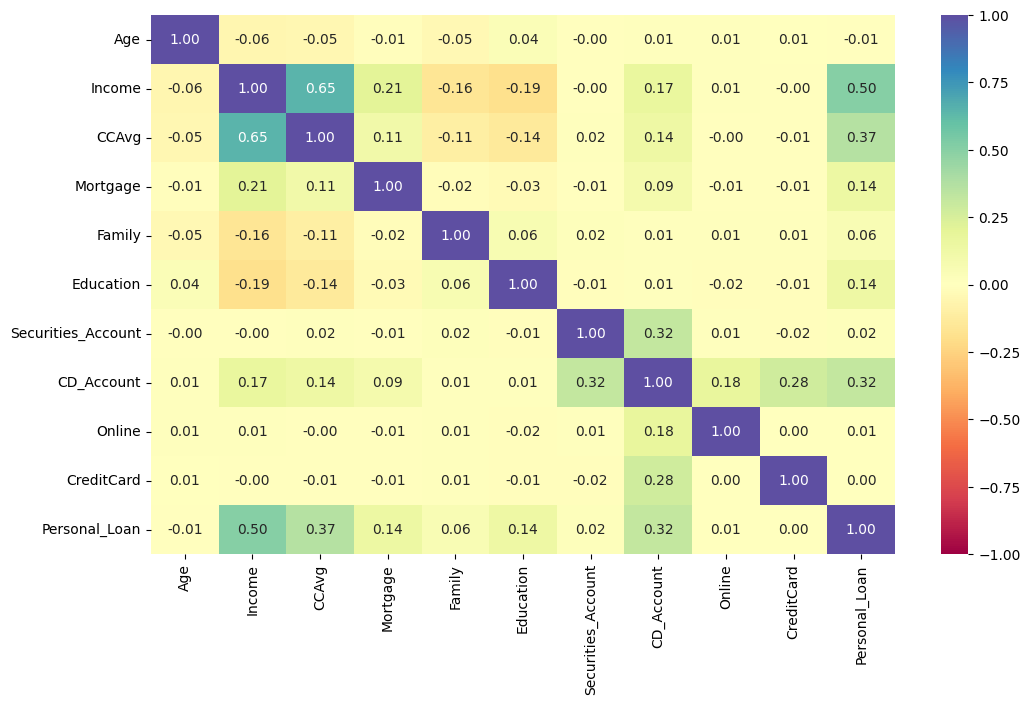

In [ ]:
# defining the size of the plot
plt.figure(figsize=(12, 7))
num_features = ['Age', 'Income', 'CCAvg', 'Mortgage', 'Family', 'Education', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Personal_Loan']
# plotting the heatmap for correlation
sns.heatmap(
    df[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

* Income(0.5) and CCAvg(0.37), Education(0.14) CD_ACCount (0.32) are having high predictvie value which has moderate association with the target(Personal_Loan)
* Age (0.01), Family(0.06), Online (0.01), credit card(0.00) are weaker
correlation and are low predictive value
* CD_Account has good sub predictive value with credit card and securities_Account
* The realtion between Income and CCAvg is0.65 which is moderate, so both can be kept
* Mortgage and Education are weaker predictorsand so it can be neglected

<Figure size 1200x800 with 0 Axes>

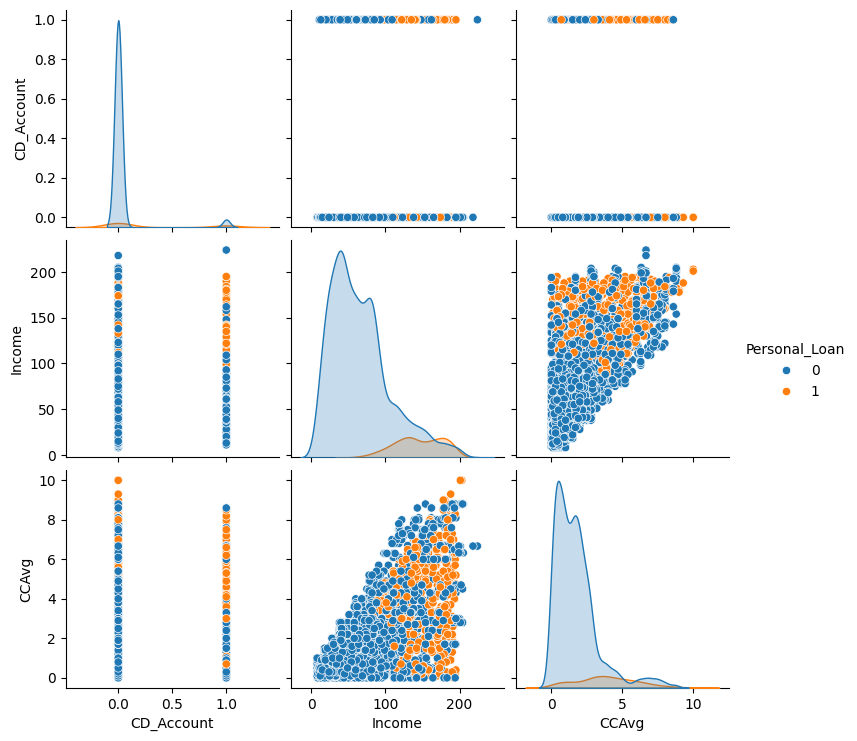

In [ ]:
# Scatter plot matrix
plt.figure(figsize=(12, 8))
num_features = ['CD_Account','Income', 'CCAvg']
sns.pairplot(df, vars=num_features, hue='Personal_Loan', diag_kind='kde');

* As Income increases, average monthly credit card spending (CCAvg) also tends to increase.
* The relationship is positive and moderately strong, but not perfect.
* Higher‑income customers generally spend more on credit cards

In [ ]:
df[['Income', 'CCAvg']].corr()


,Income,CCAvg
Income,1.000000,0.645984
CCAvg,0.645984,1.000000


It shows a moderately strong positive correlation (≈0.646) between Income and CCAvg with the target variable

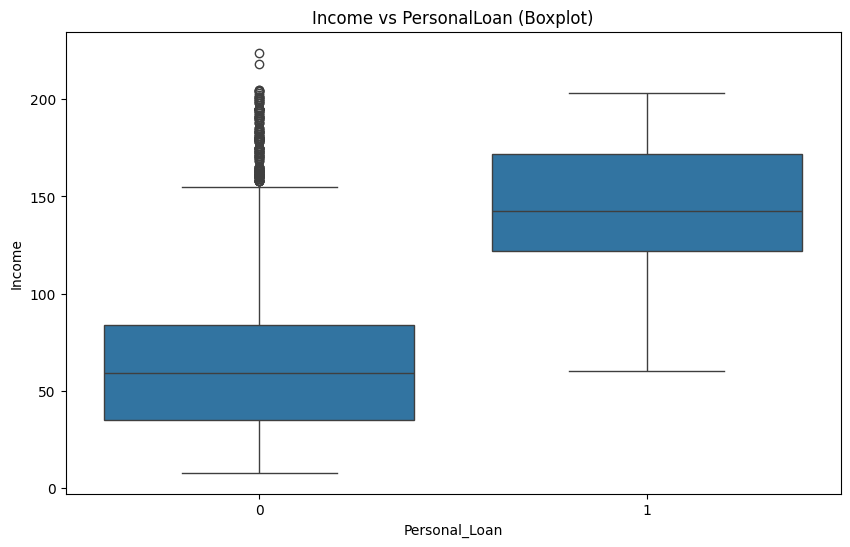

In [ ]:
# Income vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Personal_Loan', y='Income')
plt.title('Income vs PersonalLoan (Boxplot)')
plt.show()

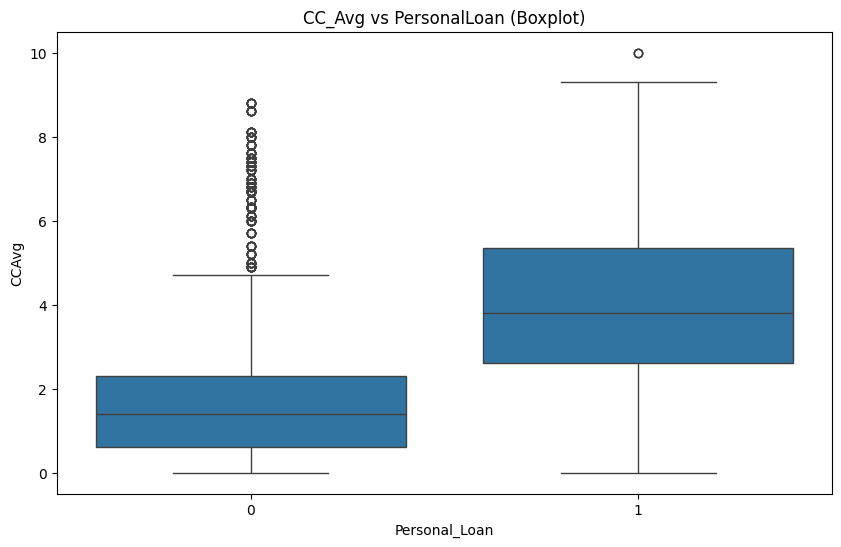

In [ ]:
# CCAvg vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Personal_Loan', y='CCAvg')
plt.title('CC_Avg vs PersonalLoan (Boxplot)')
plt.show()

Data Preparation for Modelling

In [ ]:
df = df.drop(['ID', 'ZIPCode', 'Experience'], axis=1)
df

,Age,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,29,40,1,1.9,3,0,0,0,0,1,0
4996,30,15,4,0.4,1,85,0,0,0,1,0
4997,63,24,2,0.3,3,0,0,0,0,0,0
4998,65,49,3,0.5,2,0,0,0,0,1,0


* A unique ID assigned to each customer. It contains no behavioral or demographic meaning.
* Zipcode has has too many categories and one hot encoding may create hundreds of dummy variableswhich may cause overfitting or unstable
* Experience  is almost perfectly correlated with Age.which may creates multicollinearity
* So ID, Experience and zipcode are droppedoff.

In [ ]:
df1=df.copy()

In [ ]:
# defining the explanatory (independent) and response (dependent) variables
X = df1.drop(["Personal_Loan"], axis=1)
y = df1["Personal_Loan"]
print(X,y)

      Age  Income  Family  CCAvg  Education  Mortgage  Securities_Account  \
0      25      49       4    1.6          1         0                   1   
1      45      34       3    1.5          1         0                   1   
2      39      11       1    1.0          1         0                   0   
3      35     100       1    2.7          2         0                   0   
4      35      45       4    1.0          2         0                   0   
...   ...     ...     ...    ...        ...       ...                 ...   
4995   29      40       1    1.9          3         0                   0   
4996   30      15       4    0.4          1        85                   0   
4997   63      24       2    0.3          3         0                   0   
4998   65      49       3    0.5          2         0                   0   
4999   28      83       3    0.8          1         0                   0   

      CD_Account  Online  CreditCard  
0              0       0           0

In [ ]:
# splitting the data in an 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
# stratify ensures that the training and test sets have a similar distribution of the response variable

In [ ]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (3500, 10)
Shape of test set: (1500, 10) 

Percentage of classes in training set:
Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


## Model Building

Model Evaluation

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

Confusion matrix

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

##### Decision tree (default)

In [ ]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

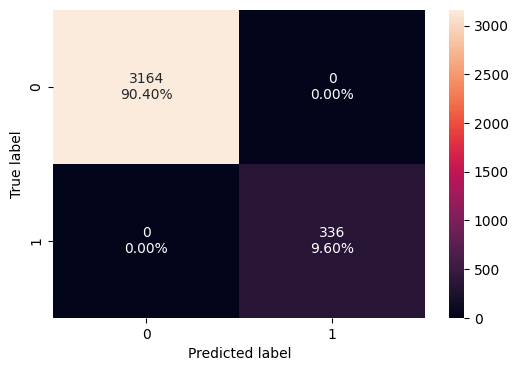

In [ ]:
plot_confusion_matrix(dtree1, X_train, y_train)

* True Negative -3164 — The model correctly identified all customers who did not take a loan.
* True Positive -336 — The model correctly identified all customers who did take a loan.

* False Positive (0) — The model never predicted “loan” for someone who didn’t take one.
* False Negative (0) — The model never missed a customer who actually took a loan.

In [ ]:
dtree1_train_perf = model_performance_classification(
    dtree1, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


It shows sign of overfitting as all are 100%

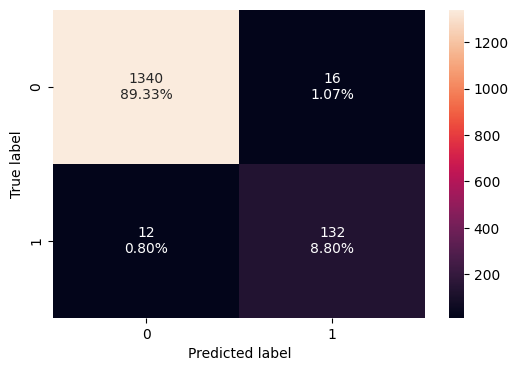

In [ ]:
plot_confusion_matrix(dtree1, X_test, y_test)

*  True Negative (1337) - customers did not take a loan, and the model correctly predicted
*  False Positive (19) - customers did not take a loan, but the model predicted
*   False Negative(13) - customers did take a loan, but the model predicted
*   True Positive (131) - customers did take a loan, and the model correctly predicted

In [ ]:
dtree1_test_perf = model_performance_classification(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.981333,0.916667,0.891892,0.90411


Visualizing the Decision Tree

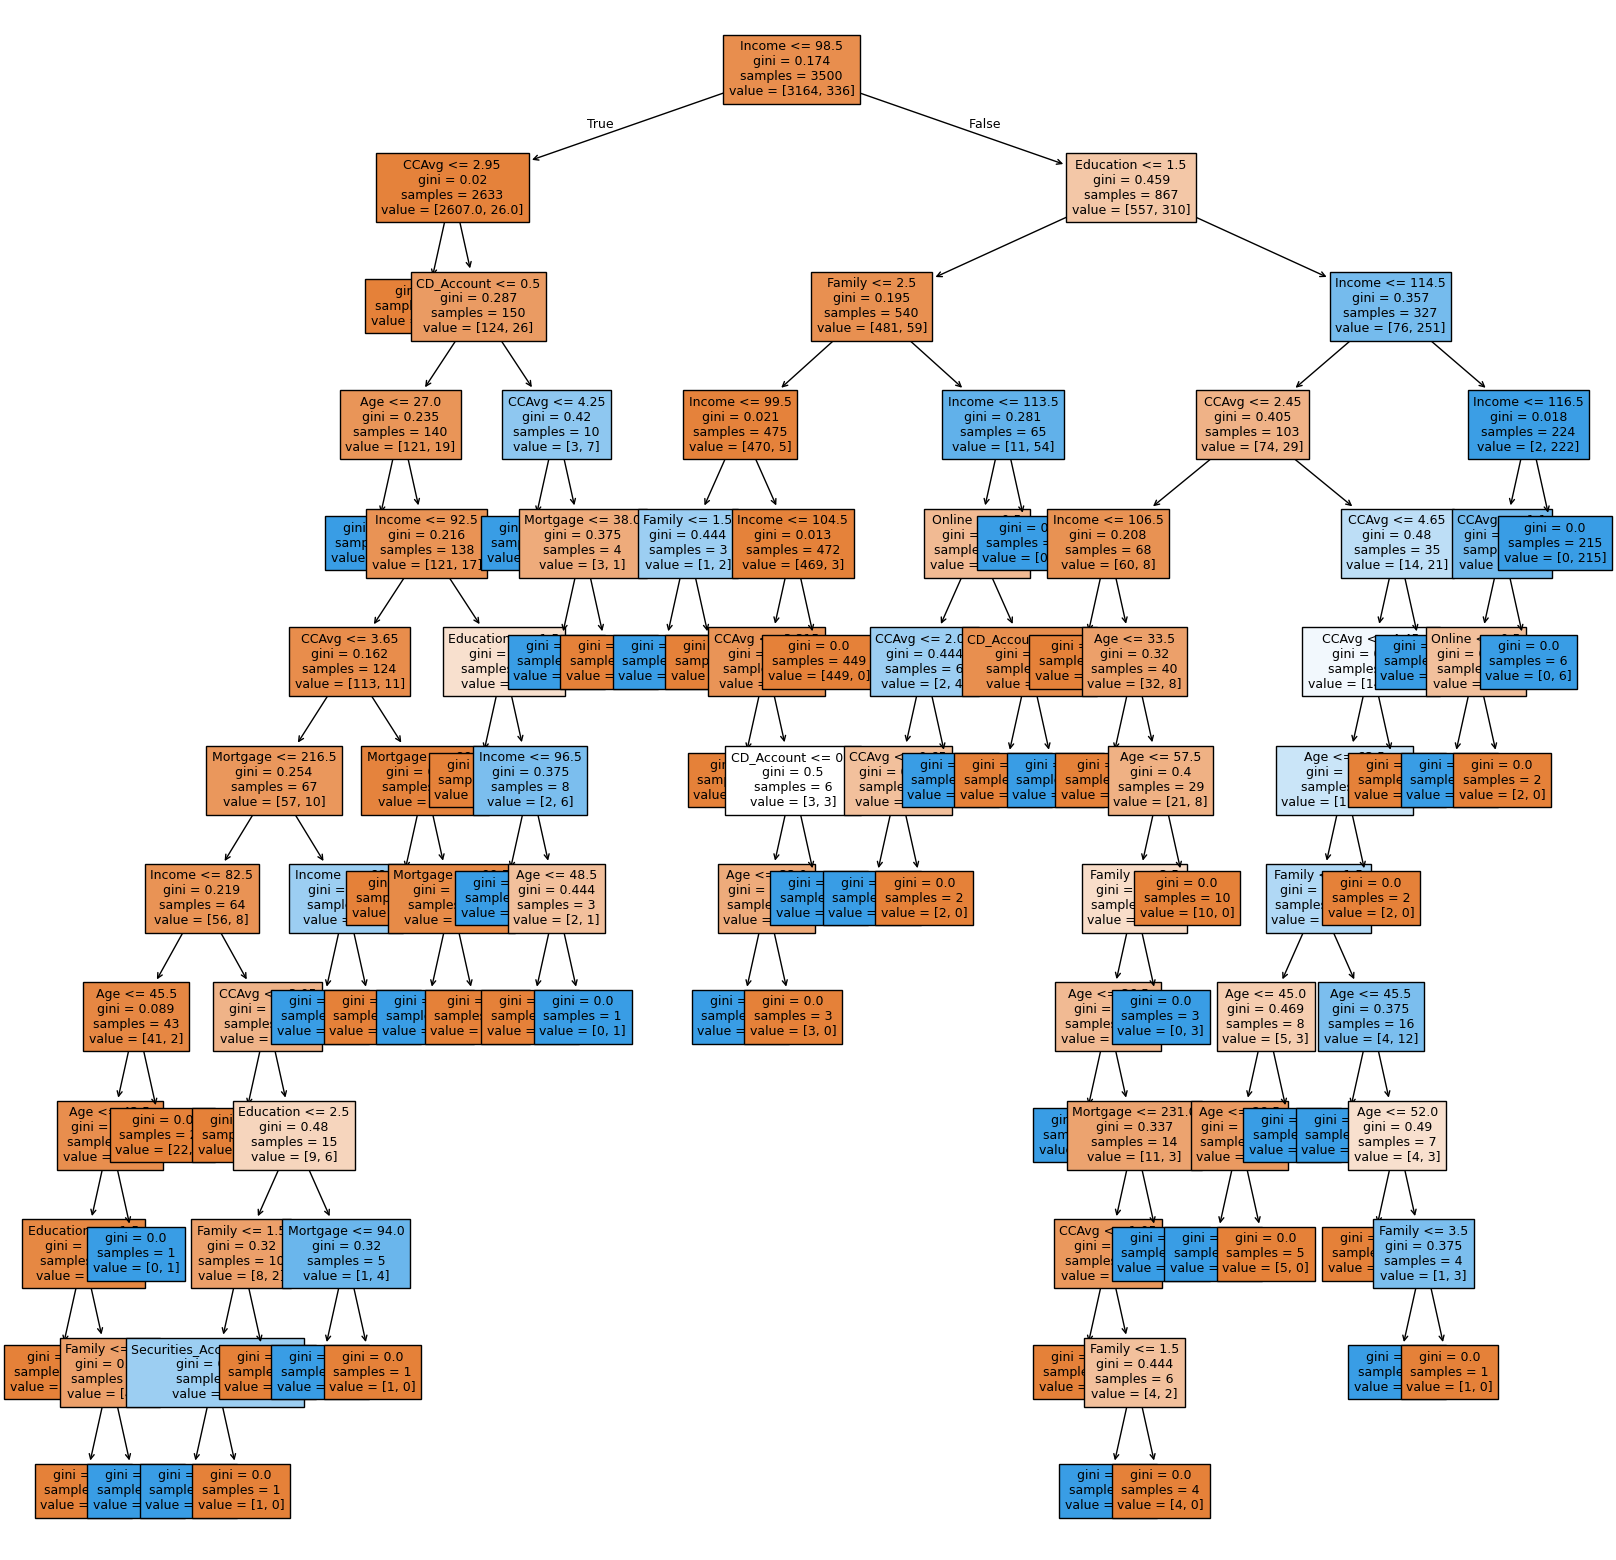

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree1,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- Income <= 92.50
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Age <= 45.50
|   |   |   |   |   |   |   |   |   |--- Age <= 43.50
|   |   |   |   |   |   |   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [15.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- Education >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- Age >  43.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |--- Age >  45.50
|

##### Decision Tree (Pre-Pruning)

In [ ]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [ ]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(4), max_leaf_nodes=np.int64(20),
                       min_samples_split=np.int64(10), random_state=42)

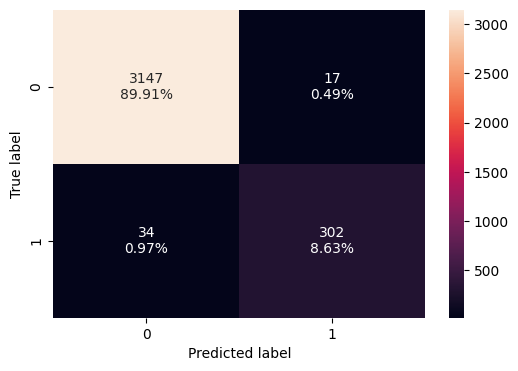

In [ ]:
plot_confusion_matrix(dtree2, X_train, y_train)

Observation:
* True Negative (3139)- customers did NOT take a loan, and the model correctly predicted
* False Positive (25) - customers did NOT take a loan, but the model predicted they would. "false alarms"
* False Negative(40) - customers DID take a loan, but the model predicted they would not.
True Postive (296) - customers DID take a loan, and the model correctly predicted them as 1.

In [ ]:
decision_tree_tune_perf_train = model_performance_classification(
    dtree2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.985429,0.89881,0.946708,0.922137


Observation:

* . A recall of 88.10% means the model misses about 12% of customers who would take a loan. This represents lost revenue opportunities
*  At 92.21%,precision, the model makes very few false positive errors.This refers
which leads to unnecessary waste of cost
*  A value of 0.90 F1score, shows the model maintains a strong equilibrium: it captures most loan‑takers while keeping false alarms low.





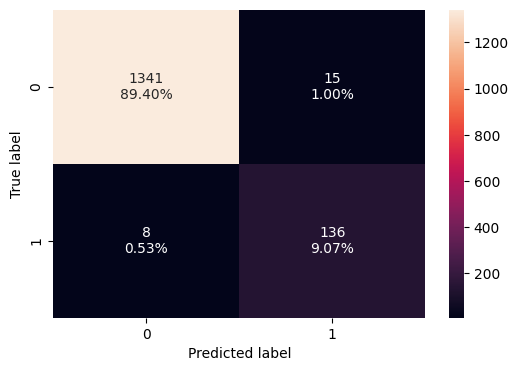

In [ ]:
plot_confusion_matrix(dtree2, X_test, y_test)

TN = 1334 (88.93%)

FP = 22 (1.47%)

FN = 8 (0.53%)

TP = 136 (9.07%)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification(
    dtree2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.984667,0.944444,0.900662,0.922034


True Negatives: 3139 → 1334 (slight drop in %)
The model remains very strong at identifying non loan customers.
Train: 89.69% : Test: 88.93% .
This shows good generalization
* False Positives: 25 → 22 (slight increase in %)
Train FP%: 0.71% : Test FP%: 1.47%
The model predicts a few more non‑loan customers as loan‑takers in the test set.
* False Negatives: 40 → 8 (big improvement!)
Train FN%: 1.14% : Test FN%: 0.53%
The model misses fewer actual loan takers in the test set
* True Positives: 296 → 136 (improved %)
Train TP%: 8.46% : Test TP%: 9.07%
The model identifies a slightly higher proportion of actual loan‑takers in the test set

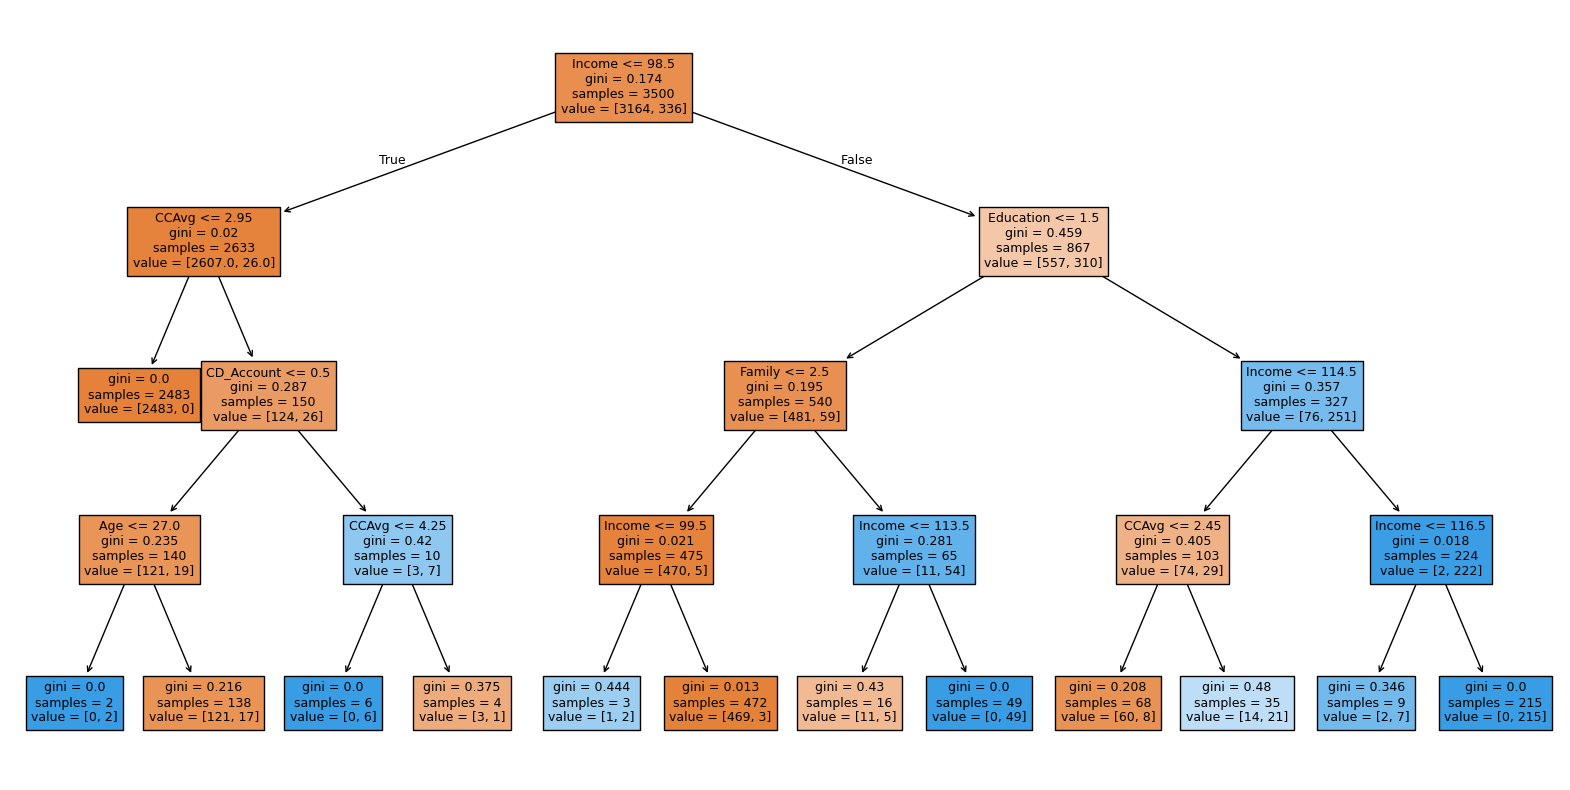

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    dtree2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(dtree2, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- weights: [121.00, 17.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- CCAvg <= 4.25
|   |   |   |   |--- weights: [0.00, 6.00] class: 1
|   |   |   |--- CCAvg >  4.25
|   |   |   |   |--- weights: [3.00, 1.00] class: 0
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 99.50
|   |   |   |   |--- weights: [1.00, 2.00] class: 1
|   |   |   |--- Income >  99.50
|   |   |   |   |--- weights: [469.00, 3.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- weights: [11.00, 5.00] class: 0
|   |   |   |--- Income >  113.50
|   |   |   |   |--- weights: [0.00, 49.00] class: 1
|   |--- Education >  1.50
|   |   |---

### Decision Tree(PostPruning)

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-8.560893e-17
1,1.052677e-19,-8.550366e-17
2,1.052677e-19,-8.539840e-17
3,5.263383e-19,-8.487206e-17
4,1.543926e-18,-8.332813e-17
5,1.543926e-18,-8.178421e-17
6,1.982541e-18,-7.980167e-17
7,3.298387e-18,-7.650328e-17
8,8.105611e-18,-6.839767e-17
9,1.652118e-17,-5.187649e-17


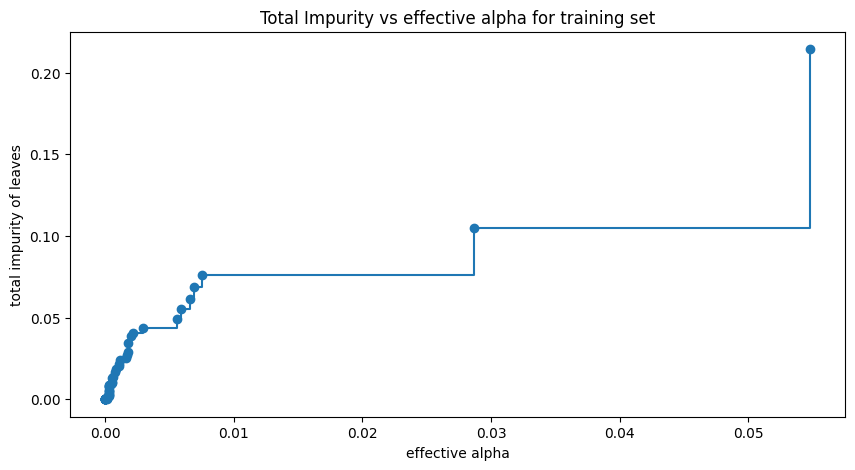

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Observation:
CCp -alpha value= 0.2857111

* Unpruned tree → 100% training accuracy (overfitting)
* Pruned tree → ~98% accuracy, better recall/precision balance
* Test performance improved and stabilized

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.28571108440376247


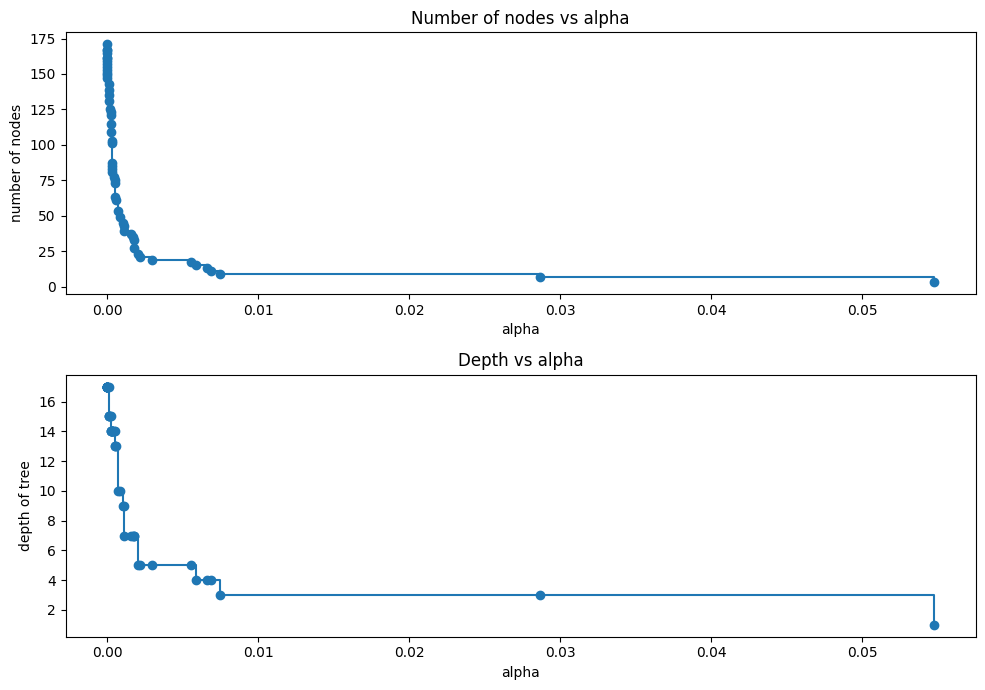

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

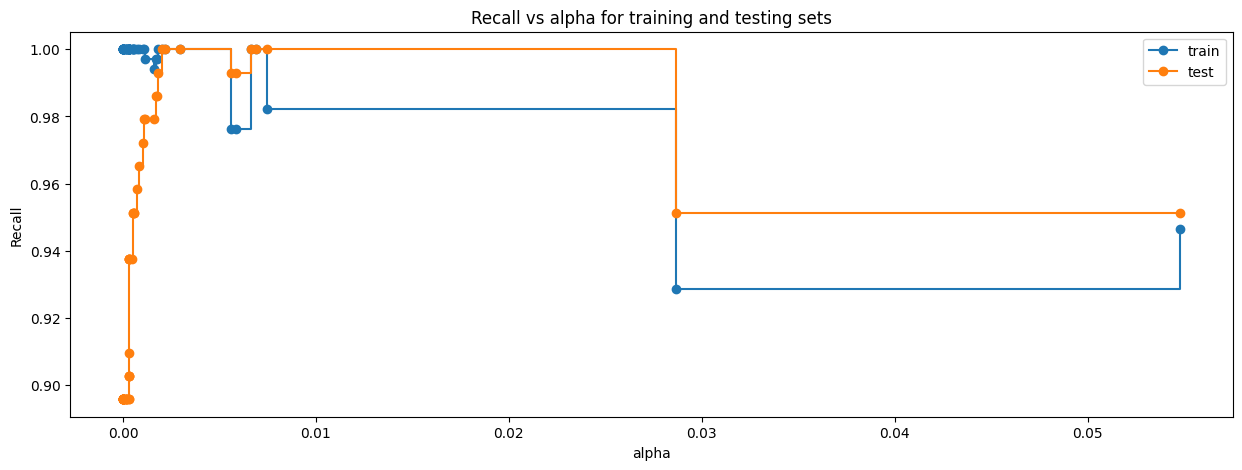

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0020324228398762205),
                       class_weight='balanced', random_state=1)


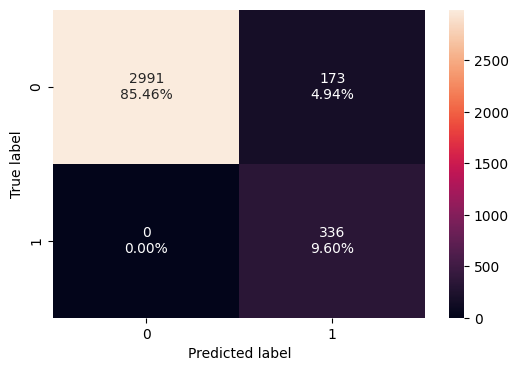

In [ ]:
model4 = best_model
plot_confusion_matrix(model4, X_train, y_train)

Observation:
True Negative : 2952 — 84.34%  
The model correctly identifies most non loan customers, but less than the pruned tree.

False Positive : 212 — 6.06%  
This is a large jump in false positives compared to earlier models.
The model is predicting “loan taker” more aggressively.

False Negative : 0 — 0.00%  
This is the standout result:
the model does not miss a single actual loan taker.

True Positive : 336 — 9.60%  
All loan takers are correctly identified.

In [ ]:
decision_tree_post_perf_train = model_performance_classification(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.950571,1.0,0.660118,0.795266


* Recall is perfect (1.0)The model captures every loan‑taker in the training set.
* Precision drops because FP increases
Predicting more positives increases false alarms.

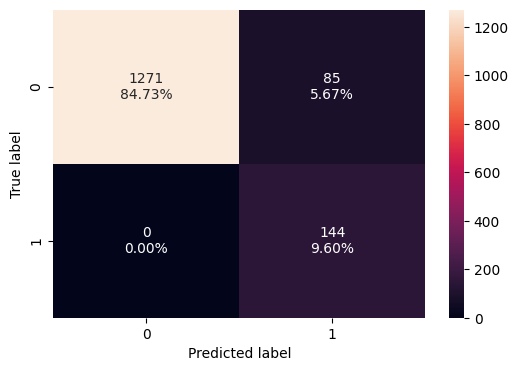

In [ ]:
plot_confusion_matrix(model4, X_test, y_test)

In [ ]:
decision_tree_post_test = model_performance_classification(
    model4, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.943333,1.0,0.628821,0.772118




*  Precision drops to 59%, meaning:
*  REcall=1.0 - No false negatives



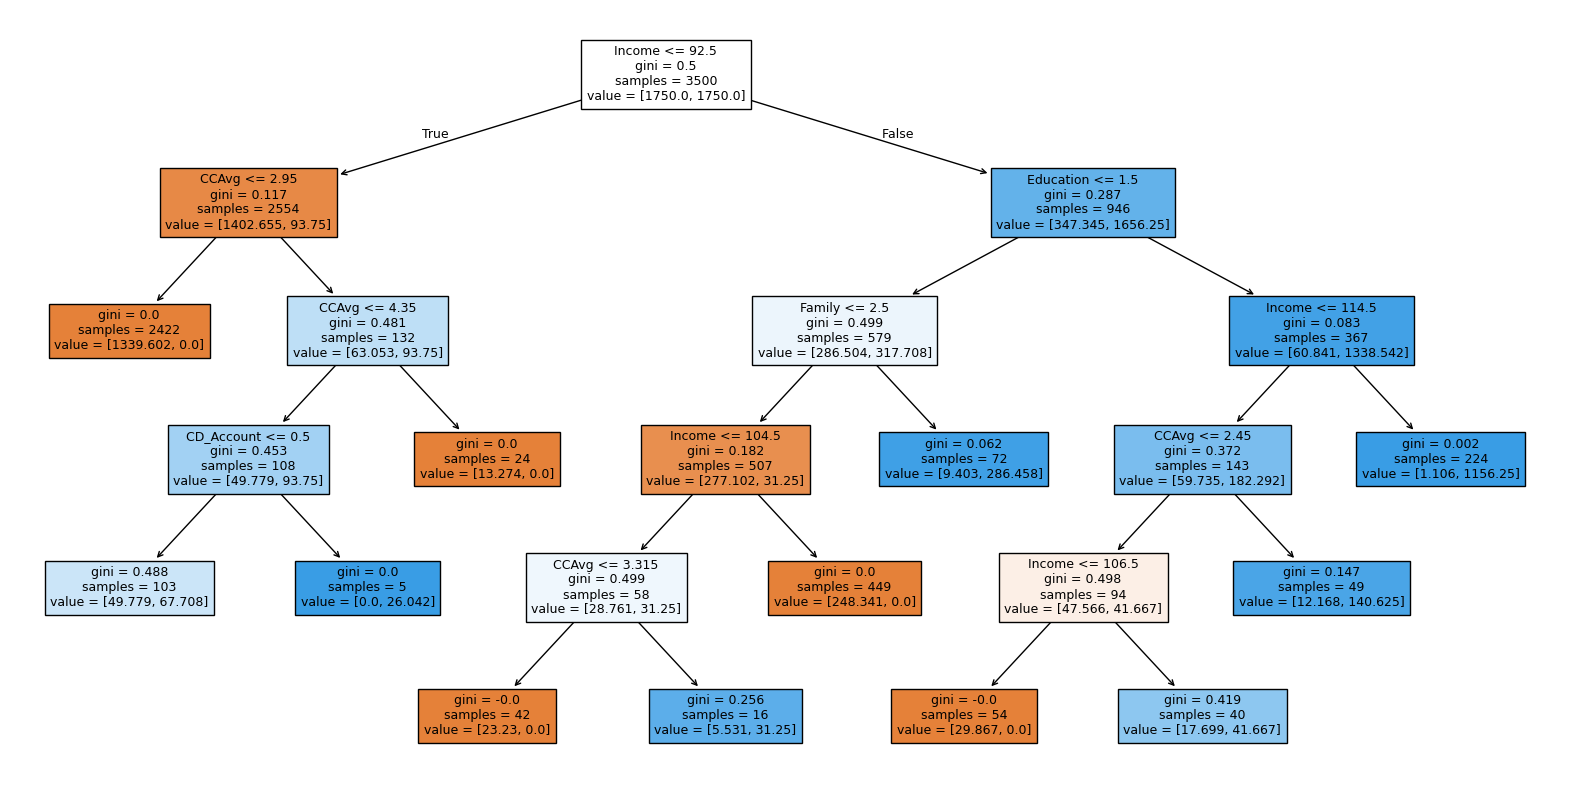

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1339.60, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.35
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- weights: [49.78, 67.71] class: 1
|   |   |   |--- CD_Account >  0.50
|   |   |   |   |--- weights: [0.00, 26.04] class: 1
|   |   |--- CCAvg >  4.35
|   |   |   |--- weights: [13.27, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- CCAvg <= 3.31
|   |   |   |   |   |--- weights: [23.23, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.31
|   |   |   |   |   |--- weights: [5.53, 31.25] class: 1
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [248.34, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [9.40, 286.46] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.45
|   |   |   |   |--- Income <= 106.50
|   |   |   |   | 

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [

        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [

    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.985429,0.950571
Recall,0.898810,1.000000
Precision,0.946708,0.660118
F1,0.922137,0.795266


* Accuracy drops because the pruned tree is simpler and no longer memorizes the training data.
*  Recall jumps to perfect catches every loan taker in training set.
* Precision drops sharply. This increases false positives, which is the cost of achieving perfect recall
* F1 falls because the balance between precision and recall becomes uneven.






In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [

        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [

    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.984667,0.943333
Recall,0.944444,1.000000
Precision,0.900662,0.628821
F1,0.922034,0.772118


Pre-Pruned decision tree is better model for effective personal loan marketing
* high recall (94%) → captures most loan‑takers
* high precision (86%) → avoids wasted outreach
* high F1 (0.90) → balanced performance
* high accuracy (98%) → strong generalization

## Actionable Insights and Business Recommendations


**Select the Pre Pruned Decision Tree as the final model.**
It provides the best balance between:
* Capturing true loan takers (high recall)
* Avoiding wasted marketing effort (high precision)
* Strong generalization (high accuracy and F1 on test data)

Business Insights and Recommendation

* High- income customers with high credit card spending are more likely to accpet loans
* So Business should target high income, high spend customers with personalized loan offers.
* USe digital channels for customers who are already active online
* Avoid spending marketing budgets on low propensity  segments




___